<a href="https://colab.research.google.com/github/amankishor/Blog-page-strt/blob/master/chapter_appendix-tools-for-deep-learning/jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HEART SURJERY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')

EDA & data cleaning

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.info() # get info of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.describe() # describe the data

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.duplicated().sum() # check for duplicated data

np.int64(0)

In [12]:
df['HeartDisease'].value_counts() #finding what no of people have heart disease

,count
HeartDisease,
1,508
0,410


In [14]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


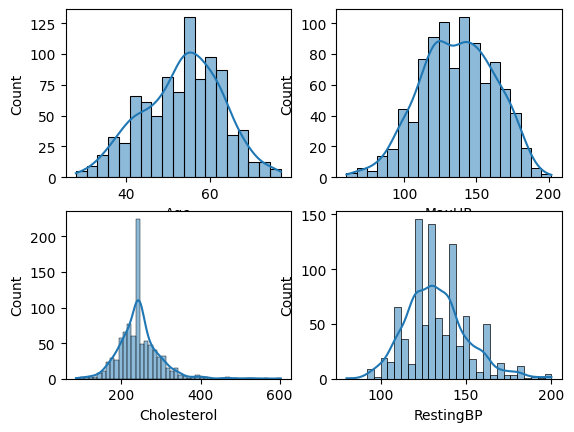

In [40]:
def plotting(var, num):
  plt.subplot(2,2,num)
  sns.histplot(df[var], kde=True) # kernel density
plotting('Age',1)
plotting('MaxHR',2)
plotting('Cholesterol',3)
plotting('RestingBP',4) # we can see the bp have value 0 no person have 0 Bp value so we have to change thi to avg



In [22]:
df['Cholesterol'].value_counts()# we can see the some people have 0 cholestrol we can change this

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [32]:
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
ch_mean
#replacing cholestrol 0 to closteral mean after finding it

np.float64(244.51633986928104)

In [33]:
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)
df['Cholesterol'] = df ['Cholesterol'].round(2)#plaing in int  we can also do round off but we are taking int(.round(2)means we can do round up upto 2 digit after point)
df['Cholesterol']

,Cholesterol
0,289
1,180
2,283
3,214
4,195
...,...
913,264
914,193
915,131
916,236


In [35]:
df['RestingBP'].value_counts()

,count
RestingBP,
120,132
130,118
140,107
110,58
150,55
...,...
101,1
117,1
192,1


In [38]:
BP_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
BP_mean

np.float64(132.54089422028352)

In [39]:
df['RestingBP'] = df['RestingBP'].replace(0, BP_mean)
df['RestingBP'] = df ['RestingBP'].round(2)#plaing in int  we can also do round off but we are taking int(.round(2)means we can do round up upto 2 digit after point)
df['RestingBP']

,RestingBP
0,140.0
1,160.0
2,130.0
3,138.0
4,150.0
...,...
913,110.0
914,144.0
915,130.0
916,130.0


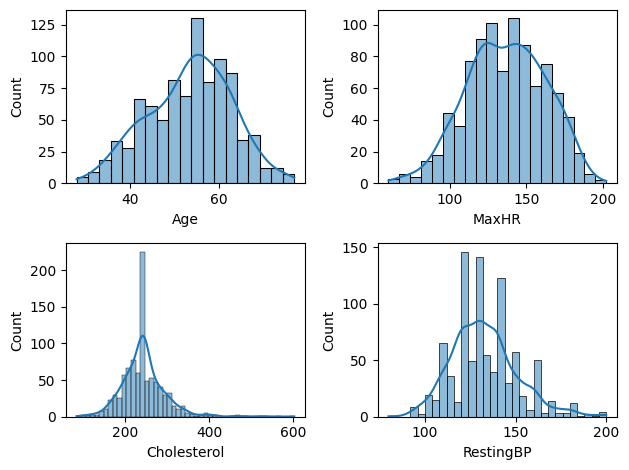

In [41]:
def plotting(var, num):
  plt.subplot(2,2,num)
  sns.histplot(df[var], kde=True) # kernel density
plotting('Age',1)
plotting('MaxHR',2)
plotting('Cholesterol',3)
plotting('RestingBP',4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

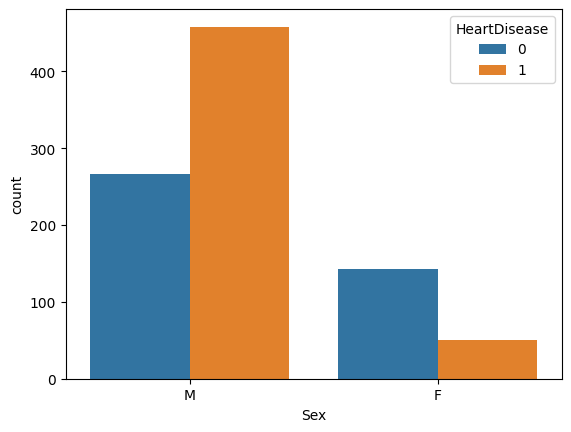

In [46]:
sns.countplot(x=df['Sex'] , hue= df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

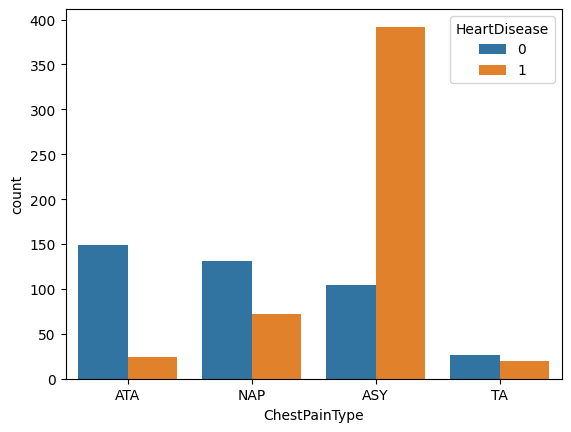

In [47]:
sns.countplot(x=df['ChestPainType'] , hue= df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

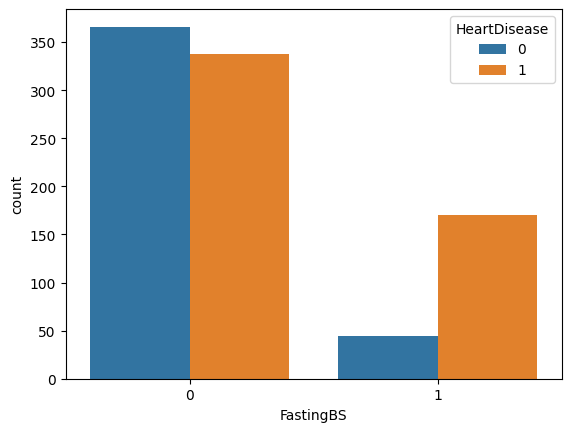

In [48]:
sns.countplot(x=df['FastingBS'] , hue= df['HeartDisease'])
#

<Axes: xlabel='Cholesterol'>

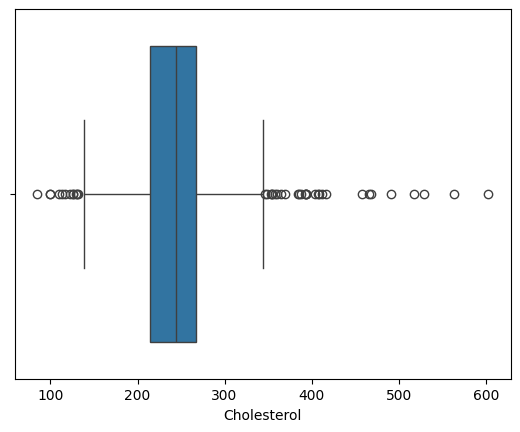

In [49]:
sns.boxplot(x='Cholesterol' , data =df)#creating box plot can compare numeric and catogorical variable

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

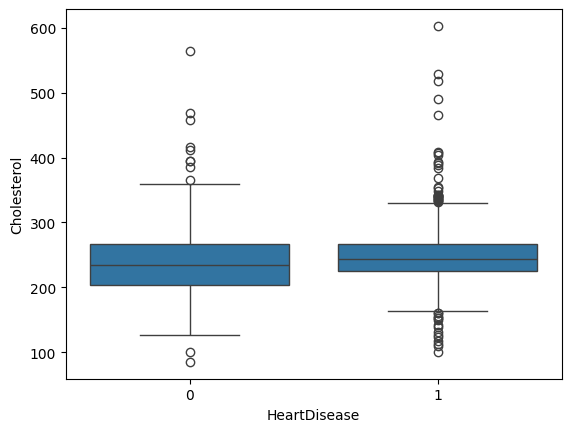

In [51]:
sns.boxplot(x='HeartDisease' , y='Cholesterol' , data =df)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

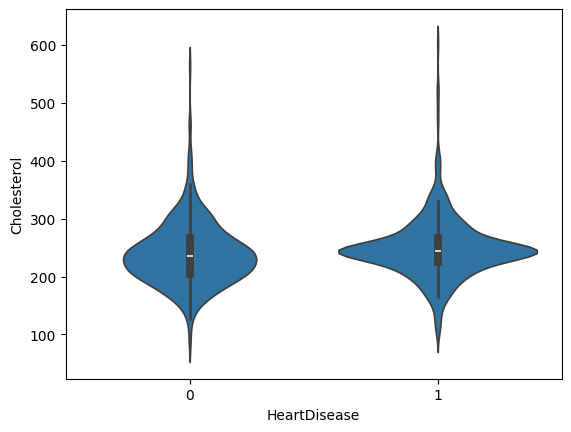

In [54]:
sns.violinplot(x='HeartDisease' , y='Cholesterol' , data =df)# it is just like boxplot but it describe the destribution

<Axes: xlabel='HeartDisease', ylabel='Age'>

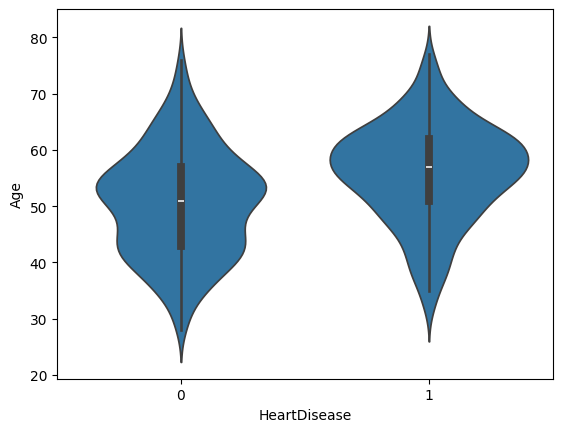

In [55]:
sns.violinplot(x='HeartDisease' , y='Age' , data =df)# it is just like boxplot but it describe the destribution

<Axes: >

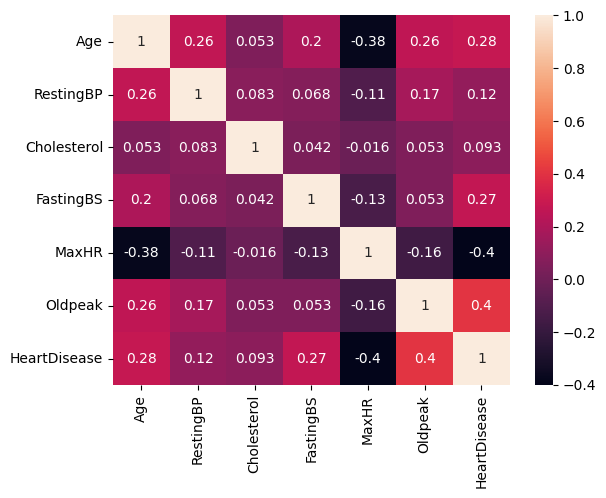

In [59]:
sns.heatmap(df.corr(numeric_only=True), annot=True)#finding co-relation with each other what wre corelation of the data points

In [61]:
df_encode =pd.get_dummies(df,drop_first=True)
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [63]:
df_encode = df_encode.astype(int) # changi bollen value to numeric
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [66]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode #we are using sklearn for standrad scaling

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253622,0.365619,0,-0.188999,0.282891,1,1,0,0,1,1,0,0,1,0
914,1.536902,0.637353,-0.966725,1,0.164684,2.303858,1,1,0,0,0,1,0,0,1,0
915,0.370100,-0.141284,-2.130180,0,-0.857069,0.282891,1,1,0,0,0,1,0,1,1,0
916,0.370100,-0.141284,-0.159813,0,1.461525,-0.727592,1,0,1,0,0,0,0,0,1,0
